# Laboratorijska vježba 1 — manipulacija slikama i prostori boja

Rješenja svih zadataka iz priloženih uputa. Slike su uključene u mapu `images`, pa je bilježnica prenosiva na GitHub i Google Colab.

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

IMG = Path('images')

def show(images, titles, cmaps=None, figsize=(15, 5)):
    """Prikaži jednu ili više slika bez skrivene promjene raspona vrijednosti."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    if cmaps is None:
        cmaps = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 1. Prikaz pojedinačnih kanala

U svakoj rezultantnoj RGB slici zadržava se samo jedan kanal, a preostala dva postavljaju se na nulu.

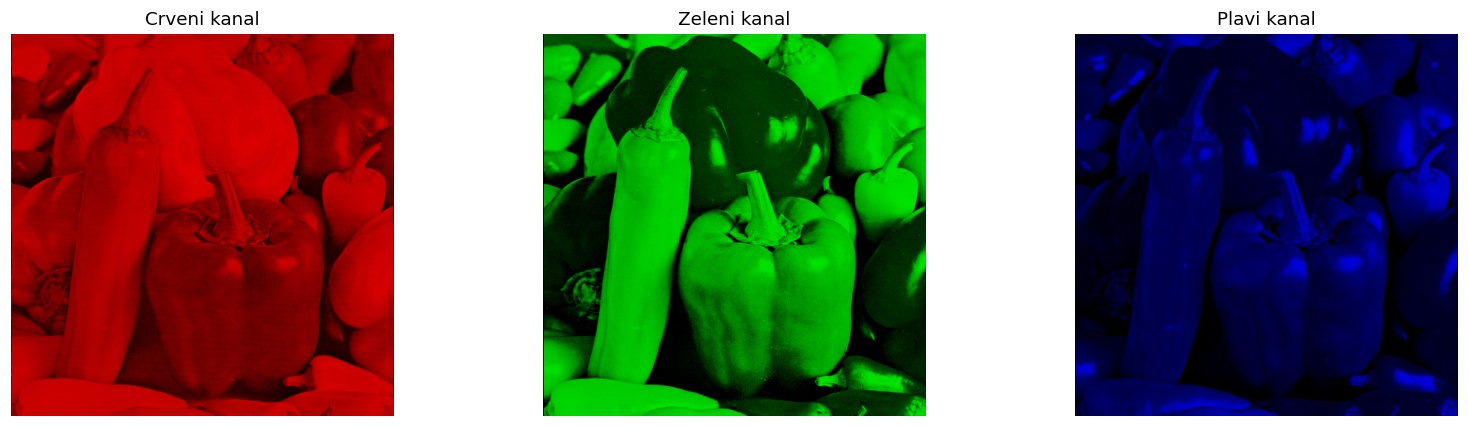

In [2]:
img_bgr = cv.imread(str(IMG / 'peppers.png'))
assert img_bgr is not None, 'Slika nije pronađena.'
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

channel_images = []
for channel in range(3):
    isolated = np.zeros_like(img_rgb)
    isolated[:, :, channel] = img_rgb[:, :, channel]
    channel_images.append(isolated)

show(channel_images, ['Crveni kanal', 'Zeleni kanal', 'Plavi kanal'], figsize=(15, 4))

## 2. Obrub širine 10 piksela

Koristi se `copyMakeBorder`; vrijednost obruba odabrana je kao bijela radi jasne vidljivosti.

Izvorne dimenzije: (512, 512, 3) | Dimenzije s obrubom: (532, 532, 3)


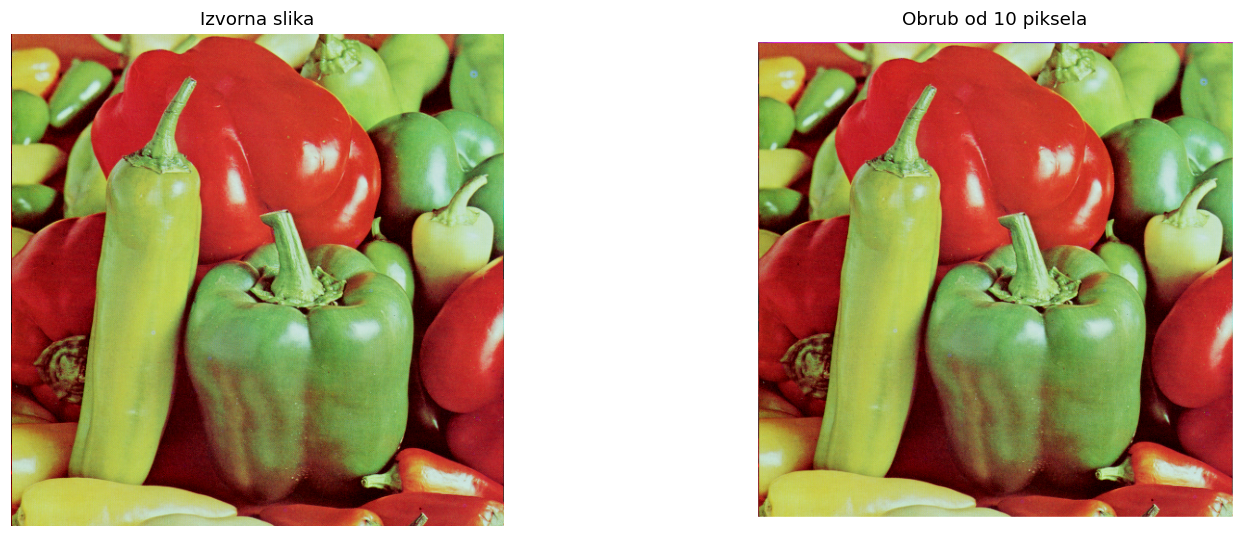

In [3]:
bordered = cv.copyMakeBorder(
    img_rgb, 10, 10, 10, 10,
    borderType=cv.BORDER_CONSTANT,
    value=(255, 255, 255)
)
show([img_rgb, bordered], ['Izvorna slika', 'Obrub od 10 piksela'])
print('Izvorne dimenzije:', img_rgb.shape, '| Dimenzije s obrubom:', bordered.shape)

## 3. Uzimanje svakog drugog piksela

Rezanje `::2` zadržava svaki drugi redak odnosno stupac, bez interpolacije.

Izvorna: (512, 512, 3)
Pola redaka: (256, 512, 3) | pola stupaca: (512, 256, 3) | oba smjera: (256, 256, 3)


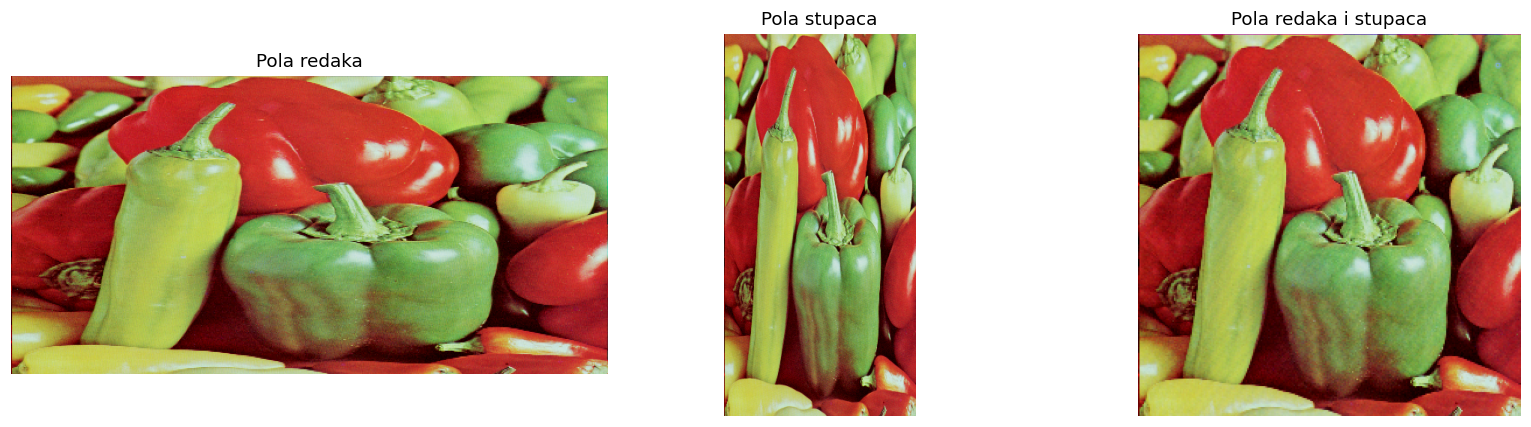

In [4]:
half_rows = img_rgb[::2, :, :]
half_cols = img_rgb[:, ::2, :]
half_both = img_rgb[::2, ::2, :]

show(
    [half_rows, half_cols, half_both],
    ['Pola redaka', 'Pola stupaca', 'Pola redaka i stupaca'],
    figsize=(15, 4)
)
print('Izvorna:', img_rgb.shape)
print('Pola redaka:', half_rows.shape, '| pola stupaca:', half_cols.shape,
      '| oba smjera:', half_both.shape)

## 4. HSV — pomak nijanse za 30

OpenCV kodira H u rasponu 0–179. Modularno zbrajanje sprječava prelijevanje tipa `uint8` i čuva kružnu prirodu nijanse.

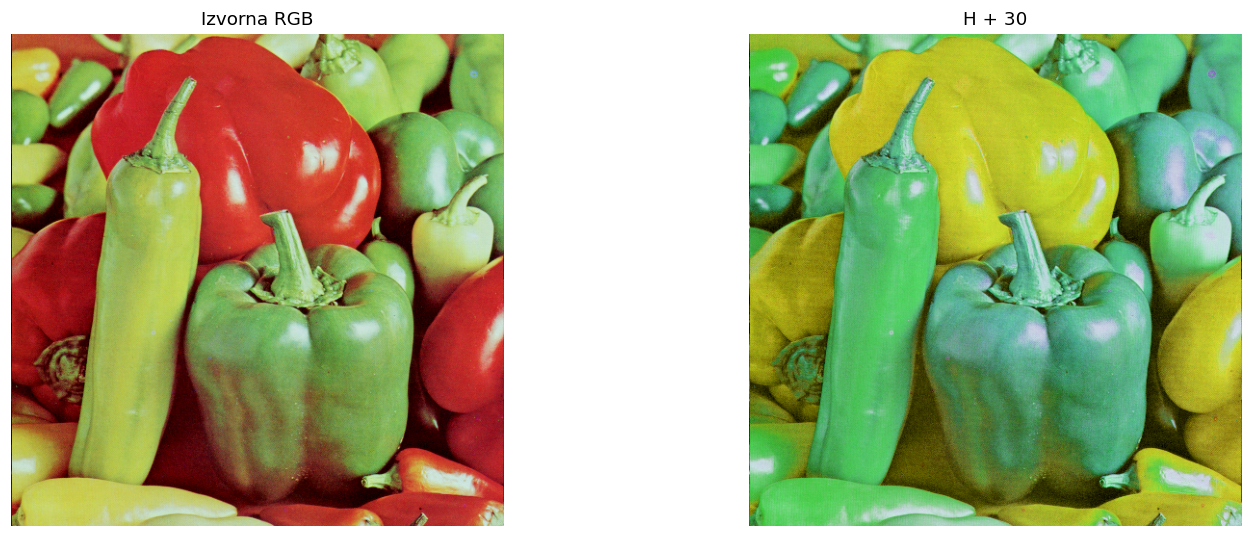

In [5]:
hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
hsv_shifted = hsv.copy()
hsv_shifted[:, :, 0] = (hsv_shifted[:, :, 0].astype(np.int16) + 30) % 180
shifted_rgb = cv.cvtColor(hsv_shifted, cv.COLOR_HSV2RGB)
show([img_rgb, shifted_rgb], ['Izvorna RGB', 'H + 30'])

## 5. HSV — postavljanje nijanse na nulu

H = 0 daje crvenu nijansu, dok zasićenost i svjetlina ostaju nepromijenjene.

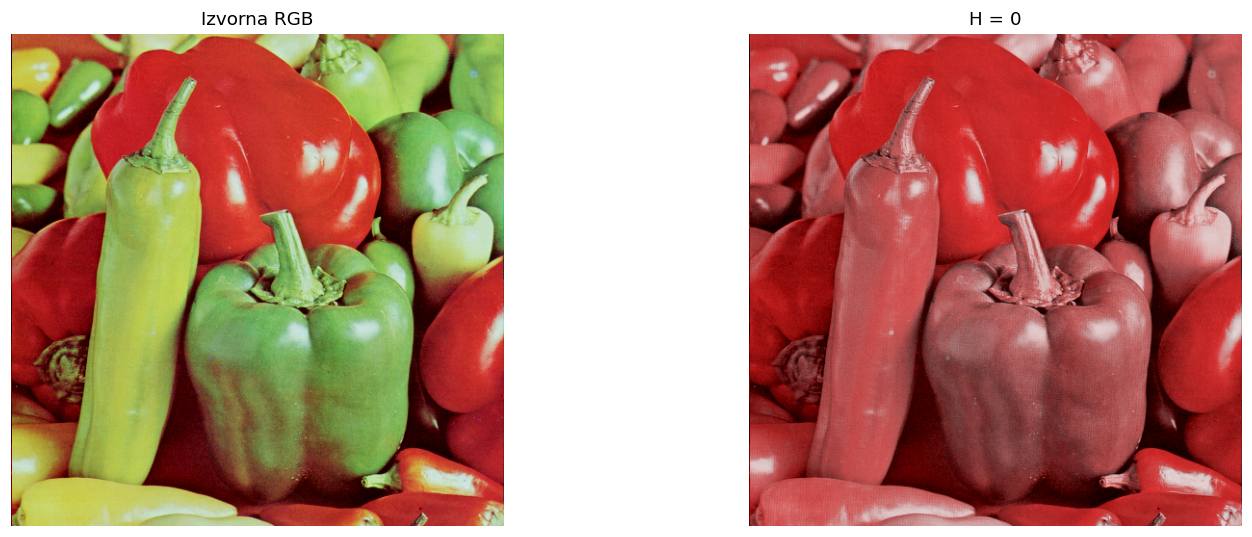

In [6]:
hsv_red = hsv.copy()
hsv_red[:, :, 0] = 0
red_rgb = cv.cvtColor(hsv_red, cv.COLOR_HSV2RGB)
show([img_rgb, red_rgb], ['Izvorna RGB', 'H = 0'])

## Zaključak

Izolacija kanala pokazuje aditivnu strukturu RGB prikaza. Rezanje mijenja prostornu rezoluciju, dok promjena samo H kanala mijenja nijansu bez izravne promjene svjetline i zasićenosti.